_______
 
# **Ex-4**

______




## **Aim** :
### Implement data mining on non-clinical data to perform chronic disease management.

This Exercise aims to perform data exploration and clustering on a set of non-clinical
data features, with visualization at key stages to help understand the data.
#### **Data mining** is used to analyze and uncover patterns in this data

______
## Non-Clinical Data

**Non-clinical data** refers to lifestyle, behavioral, and environmental information that affects health. This data includes information about individuals that isn't directly related to their medical history, diagnoses, or treatments. Instead, it focuses on factors that might influence health or well-being.

### Key Factors
*   **Lifestyle choices:** e.g., physical activity, smoking, alcohol consumption.
*   **Socioeconomic factors:** e.g., age, income, education.
*   **Behavioral factors:** e.g., diet, sleep patterns.
*   **Environmental factors:** e.g., location, air quality.

> **Summary:** Non-clinical data helps provide a broader understanding of the factors that may contribute to a person’s overall health or the risk of developing chronic diseases.
_____

## Chronic Disease Management

**Chronic diseases** are long-term health conditions, such as diabetes, heart disease, and chronic respiratory diseases. These conditions are often preventable or manageable through lifestyle changes, medication, and monitoring.

### The Role of Non-Clinical Data
Chronic disease management aims to prevent and manage long-term diseases. **Non-clinical data** assists this process by identifying risk factors and guiding interventions to improve health outcomes.

#### Benefits of Mining Non-Clinical Data:
*   **Identify At-Risk Individuals:** Flag individuals with habits such as smoking, poor physical activity, or an unhealthy BMI who may be more likely to develop chronic conditions.
*   **Create Personalized Interventions:** Healthcare professionals can suggest tailored strategies based on an individual's specific lifestyle to reduce their specific risk profile.
*   **Improve Disease Prevention:** Predict future risks and recommend proactive actions, such as exercise, dietary changes, or smoking cessation.
_______

## Scenario: Data-Driven Risk Identification

In this scenario, we assume a healthcare provider has access to a dataset containing non-clinical factors:
*   **Demographics:** Age
*   **Physical Metrics:** BMI (Body Mass Index)
*   **Lifestyle Habits:** Smoking habits, physical activity levels, and alcohol consumption.

### The Insight
Using **data mining techniques**, the provider might discover specific patterns—for instance, that individuals with a **high BMI**, who **smoke**, and **lack regular exercise** face a significantly higher risk of developing heart disease.

### The Action
By identifying these patterns early, the provider can:
1.  **Offer personalized advice** tailored to the individual's habits.
2.  **Deploy interventions** to manage risk factors proactively.
3.  **Prevent disease progression** before clinical symptoms even appear.

---
> **Programming Example:** The following code demonstrates how we can process and analyze these specific variables.


## Step 0 : Import Necessary Libraries



In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

> - **Explanation :**
- **Pandas** : Data manipulation and analysis (often used for working with DataFrames/Tabular Data).
- **NumPy** : Numerical computations, used to generate random data and perform mathematical operations.
- **Matplotlib.pyplot** : A plotting library used to create graphs and static visualizations.
- **Seaborn** : A data visualization library built on top of Matplotlib, offering more advanced and aesthetically pleasing plots.
- **StandardScaler** : A preprocessing tool to standardize data so that each feature has a mean of $0$ and a standard deviation of $1$.
- **PCA (Principal Component Analysis)** : A technique used to reduce the dimensionality of the data while retaining as much information (variance) as possible.
- **KMeans** : A popular clustering algorithm used to group data into $k$ number of clusters based on similarity.


____
## Step 1 : Load the Data(creating the Data)

In [22]:
data = {
    'Age' : np.random.randint(20,80,100),
    'BMI' : np.random.randint(19,35,100),
    'Smoking' : np.random.randint(0,2,100),
    'AlcoholConsumption' : np.random.randint(0,4,100),
    'PhysicalActivity' : np.random.randint(0,4,100),
    'ChronicDisease' : np.random.randint(0,2,100)
}


We define a dictionary where each **key** is a feature and each **value** is an array of random integers generated via `np.random.randint()`.

#### **Data Dictionary Breakdown:**
*   **Age**: Random integers between $20$ and $80$ (100 samples).
*   **BMI**: Random integers between $18$ and $35$ (Body Mass Index).
*   **Smoking**: Binary values ($0$ or $1$) representing smoking status.
*   **AlcoholConsumption**: Levels from $0$ to $3$.
*   **PhysicalActivity**: Activity levels ($0, 1, 2$).
*   **ChronicDisease**: Binary values ($0$ or $1$) indicating presence of disease.

---

### Converting the Data into a DataFrame


In [23]:
non_clinical_data = pd.DataFrame(data)

The dictionary data is converted into a pandas DataFrame named non_clinical_data.

#### Displaying the First Few Rows

In [24]:
(non_clinical_data.head(7))

,Age,BMI,Smoking,AlcoholConsumption,PhysicalActivity,ChronicDisease
0,26,22,0,2,0,0
1,58,21,1,0,1,1
2,51,23,0,1,0,1
3,43,25,1,1,2,0
4,72,26,1,2,3,0
5,36,27,1,3,1,0
6,54,20,0,3,0,1


In [25]:
non_clinical_data.describe()

,Age,BMI,Smoking,AlcoholConsumption,PhysicalActivity,ChronicDisease
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,46.120000,25.880000,0.480000,1.320000,1.500000,0.520000
std,17.676258,4.573264,0.502117,1.081338,1.105542,0.502117
min,20.000000,19.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,22.750000,0.000000,0.000000,0.750000,0.000000
50%,43.500000,26.000000,0.000000,1.000000,2.000000,1.000000
75%,60.250000,30.000000,1.000000,2.000000,2.000000,1.000000
max,79.000000,34.000000,1.000000,3.000000,3.000000,1.000000


_____

## Step 2 : Preprocessing of Data

In [26]:
# Check for missing values
non_clinical_data.isnull().sum()


Age                   0
BMI                   0
Smoking               0
AlcoholConsumption    0
PhysicalActivity      0
ChronicDisease        0
dtype: int64

## Standardise The Features


In [27]:
Features = ['Age','BMI','Smoking','AlcoholConsumption','PhysicalActivity']

scaler = StandardScaler()
non_clinical_data[Features] = scaler.fit_transform(non_clinical_data[Features])


> - **Process : Data Standardization**
- **Method** : The selected features (**Age**, **BMI**, **Smoking**, **AlcoholConsumption**, and **PhysicalActivity**) are processed using `StandardScaler`.
- **Function** : This transforms each feature to have a mean of $0$ and a standard deviation of $1$.
- **Importance** : This step is crucial for distance-based algorithms like **PCA** and **KMeans**, which are sensitive to the scale of the data (e.g., ensuring "Age" values don't outweigh "Smoking" values just because the numbers are larger).


In [28]:
# After stnadardization view the data once more
non_clinical_data.head()

,Age,BMI,Smoking,AlcoholConsumption,PhysicalActivity,ChronicDisease
0,-1.143984,-0.852683,-0.960769,0.632018,-1.363636,0
1,0.675474,-1.072447,1.040833,-1.226859,-0.454545,1
2,0.277467,-0.632920,-0.960769,-0.297420,-1.363636,1
3,-0.177397,-0.193392,1.040833,-0.297420,0.454545,0
4,1.471487,0.026372,1.040833,0.632018,1.363636,0


In [ ]:
non_clinical_data.describe()

,Age,BMI,Smoking,AlcoholConsumption,PhysicalActivity,ChronicDisease
count,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,100.000000
mean,1.376677e-16,1.962666e-16,-2.220446e-17,-3.996803e-17,1.110223e-17,0.520000
std,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,0.502117
min,-1.485133e+00,-1.511975e+00,-9.607689e-01,-1.226859e+00,-1.363636e+00,0.000000
25%,-9.165520e-01,-6.878606e-01,-9.607689e-01,-1.226859e+00,-6.818182e-01,0.000000
50%,-1.489681e-01,2.637165e-02,-9.607689e-01,-2.974204e-01,4.545455e-01,1.000000
75%,8.034044e-01,9.054267e-01,1.040833e+00,6.320183e-01,4.545455e-01,1.000000
max,1.869493e+00,1.784482e+00,1.040833e+00,1.561457e+00,1.363636e+00,1.000000


_____
## Step 3 : Visualize the Data using PairPlot

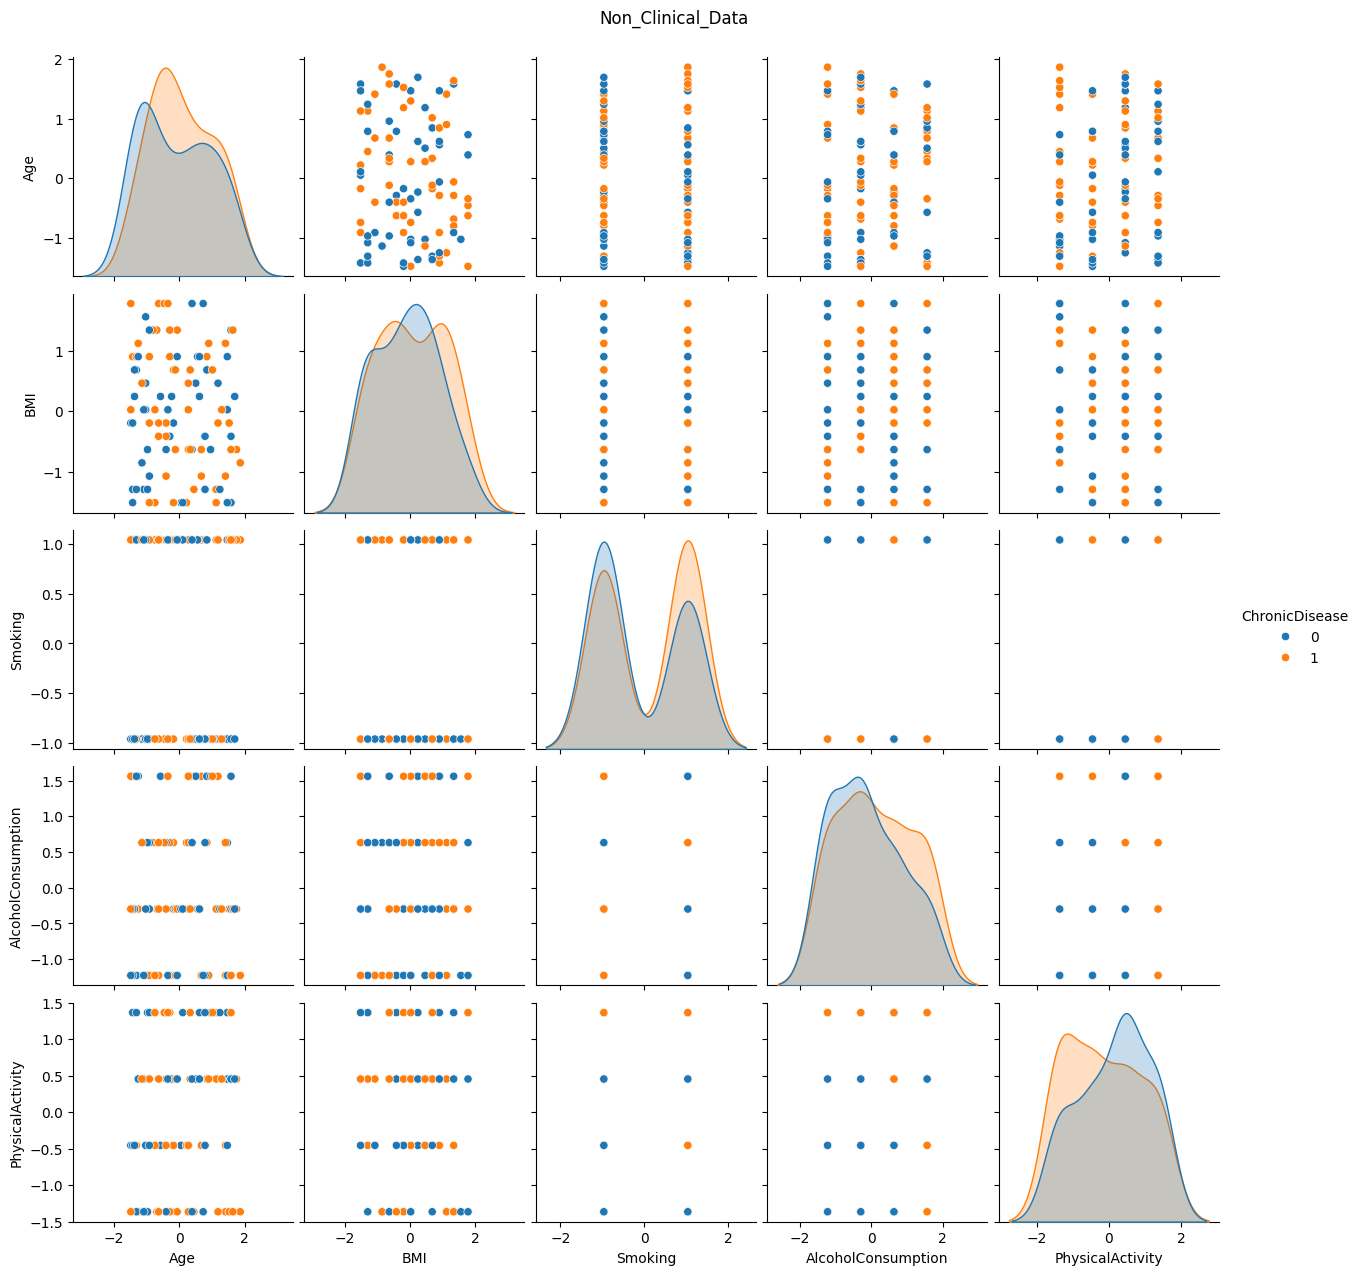

In [30]:
sns.pairplot(non_clinical_data,hue='ChronicDisease')
plt.suptitle('Non_Clinical_Data',y=1.02)
plt.show()

> - **Visualization : Pairplot**
- **Definition** : This creates a grid of scatter plots for every pair of features in the dataset.
- **Color-Coding** : Data points are colored based on the **ChronicDisease** column (the target variable).
- **Purpose** : It provides an intuitive way to visually explore relationships between features and helps identify patterns or clusters associated with chronic disease.
_____

## Step 4 : Plotting a Correlation HeatMap

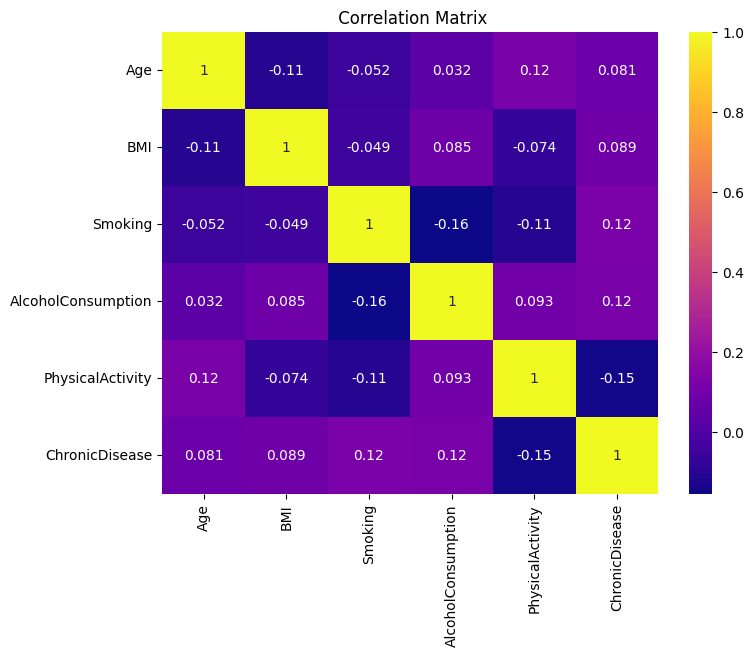

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(non_clinical_data.corr(), annot=True, cmap='plasma')
plt.title(" Correlation Matrix")
plt.show()

> - **Visualization : Correlation Heatmap**
- **Definition** : This matrix displays how strongly the features are correlated with each other, with values ranging from $-1$ (perfect negative correlation) to $1$ (perfect positive correlation).
- **`annot=True`** : This parameter overlays the actual numerical correlation values on the heatmap for better readability.
- **`cmap='coolwarm'`** : This sets the color palette; typically, "cool" (blue) represents negative correlation and "warm" (red) represents positive correlation.


_____
## Step 5 : Applying PCA (for dimentionality reduction)

In [32]:
pca = PCA(n_components=2)
principal_componets = pca.fit_transform(non_clinical_data[Features])
pca_df = pd.DataFrame(principal_componets, columns=['PC1','PC2'])
pca_df['ChronicDisease'] = non_clinical_data['ChronicDisease']

> - **Process : Principal Component Analysis (PCA)**
- **Dimensionality Reduction** : PCA reduces the dataset from **5 features** down to **2 principal components** (PC1 and PC2) while retaining as much information (variance) as possible.
- **`fit_transform()`** : This method calculates the components and performs the transformation, storing the result in `principal_components`.
- **`pca_df`** : A new DataFrame is created containing the two components and the **ChronicDisease** column, making it possible to visualize a 5-dimensional problem in a simple 2D scatter plot.


____
## Step 6 : Visualizing the PCA Results 

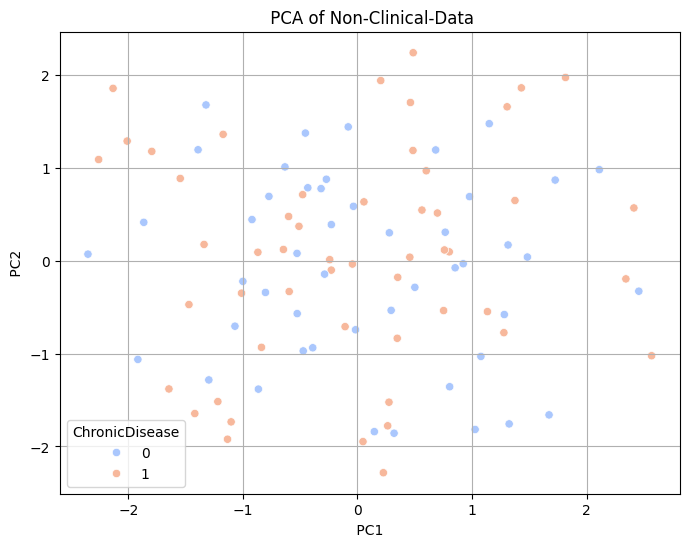

In [33]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='ChronicDisease', data=pca_df, palette='coolwarm')

plt.title(" PCA of Non-Clinical-Data")
plt.xlabel(' PC1 ')
plt.ylabel(' PC2 ')
plt.grid(True)
plt.show()



> - **Visualization : PCA Scatter Plot**
- **Definition** : This visualizes the data in a new 2-dimensional space created by the Principal Components.
- **Color-Coding** : Each point is colored based on the **ChronicDisease** status, allowing for easy observation of group separation.
- **Purpose** : It helps to determine how well the non-clinical data can be separated or clustered in a reduced-dimensional space to identify potential health patterns.


___ 
## Step : 7 Applying KMeans Clustering


kmeans = KMeans(n_clusters=2, random_state=0)
non_clinical_data['Cluster'] = kmeans.fit_predict(non_clinical_data[Features])
pca_df['Cluster'] = non_clinical_data['Cluster']
> - **Algorithm : KMeans Clustering**
- **Grouping** : `KMeans` is used to partition the data into **n_clusters=2**, aligning with the two expected groups (e.g., Higher Risk vs. Lower Risk).
- **Cluster Labels** : The algorithm assigns each data point to one of the two clusters based on feature similarity; these assignments are stored in a new **Cluster** column.
- **Integration** : These labels are added to the **pca_df** DataFrame, allowing us to visualize how the mathematical clusters overlap with the actual **ChronicDisease** status.


______
## Step 8 : Visualizing the KMeans Clusters

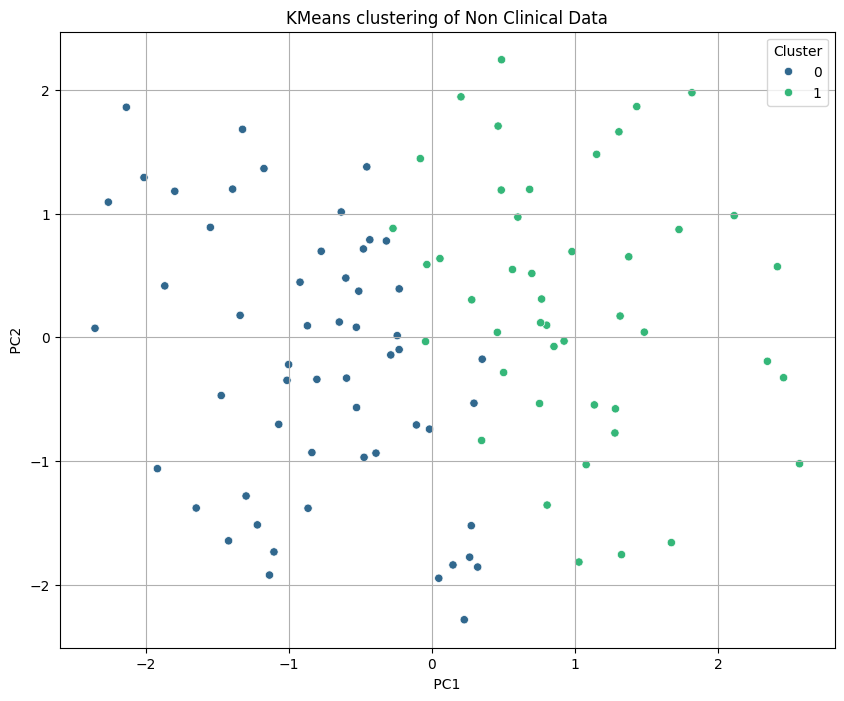

In [35]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df,palette='viridis')

plt.title("KMeans clustering of Non Clinical Data")
plt.xlabel(' PC1 ')
plt.ylabel(' PC2 ')
plt.grid(True)
plt.show()

> - **Visualization : Scatter Plot of Clusters**
- **Definition** : This plot displays the results of the **KMeans** algorithm within the 2D space generated by PCA.
- **Color-Coding** : Each data point is colored according to its assigned **Cluster** (e.g., Cluster 0 vs. Cluster 1).
- **Purpose** : It provides a visual confirmation of how the algorithm has partitioned the individuals into distinct groups based on their non-clinical risk factors.


_____
## Final Inferences and Analysis

### **1. Interpreting the Cluster Alignment**
*   **Successful Identification**: If the clusters align well with the **ChronicDisease** groups (e.g., Cluster 1 contains mostly individuals with the disease), it suggests that KMeans has identified meaningful biological and lifestyle patterns related to health outcomes.
*   **Weak Alignment**: If the clusters overlap significantly or do not match the disease labels, it suggests that the current non-clinical features alone may not be enough to capture the underlying health structure, or the relationship is non-linear.

### **2. Summary of the Analysis (Exercise 4)**
*   **Dimensionality Reduction**: **PCA** successfully condensed the 5D dataset into two principal components. The resulting scatter plot reveals whether non-clinical factors—such as **Age**, **BMI**, and **Physical Activity**—are sufficient to visually separate healthy individuals from those at risk.
*   **Predictive Potential**: The **KMeans** clustering results demonstrate our ability to group individuals based on lifestyle similarities. Strong alignment between these clusters and actual disease labels indicates that **data mining techniques** are a powerful tool for predicting chronic disease risk using only non-clinical data.
